# Exploratory Data Analysis

Understanding the structure of the airline fare dataset to motivate the Graph Neural Network approach. Key questions: how is fare distributed? what does the route graph look like? are there seasonal and geographic patterns?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import datashader as ds
import datashader.transfer_functions as tf

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

# RdBu_r accent color for single-color plots
BLUE = '#4393c3'
RED  = '#d6604d'
# Quarter color key (RdBu_r-inspired: Q1=dark blue → Q4=dark red)
Q_COLORS = {'1': '#2166ac', '2': '#74add1', '3': '#f46d43', '4': '#d73027'}

In [3]:
DATA_PATH = '../../data/clean_data/T_DB1B_MARKET_CLEAN.csv'

df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Full dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")

# 10% sample for visualizations — full dataset used for aggregate stats
df_sample = df.sample(frac=0.1, random_state=42).reset_index(drop=True)
print(f"\nSample for plots: {df_sample.shape[0]:,} rows")
df_sample.head()

Full dataset: 32,520,273 rows × 19 columns
Columns: ['YEAR', 'QUARTER', 'ORIGIN_AIRPORT_ID', 'ORIGIN', 'DEST_AIRPORT_ID', 'DEST', 'REPORTING_CARRIER', 'TICKET_CARRIER', 'OPERATING_CARRIER', 'BULK_FARE', 'PASSENGERS', 'MARKET_FARE', 'MARKET_DISTANCE', 'NONSTOP_MILES', 'MKT_GEO_TYPE', 'ORIGIN_LAT', 'ORIGIN_LON', 'DEST_LAT', 'DEST_LON']

Sample for plots: 3,252,027 rows


,YEAR,QUARTER,ORIGIN_AIRPORT_ID,ORIGIN,DEST_AIRPORT_ID,DEST,REPORTING_CARRIER,TICKET_CARRIER,OPERATING_CARRIER,BULK_FARE,PASSENGERS,MARKET_FARE,MARKET_DISTANCE,NONSTOP_MILES,MKT_GEO_TYPE,ORIGIN_LAT,ORIGIN_LON,DEST_LAT,DEST_LON
0,2025,2,13198,MCI,15304,TPA,NK,NK,NK,0.0,1.0,137.0,1439.0,1048.0,2,39.297600,-94.713898,27.975500,-82.533203
1,2024,4,13232,MDW,11259,DAL,WN,WN,WN,0.0,1.0,175.5,793.0,793.0,2,41.785999,-87.752403,32.847099,-96.851799
2,2024,4,12892,LAX,13230,MDT,AA,AA,99,0.0,1.0,617.0,2486.0,2320.0,2,33.942501,-118.407997,40.193501,-76.763397
3,2025,1,12953,LGA,11267,DAY,9E,DL,9E,0.0,1.0,174.0,549.0,549.0,2,40.777199,-73.872597,39.902401,-84.219398
4,2025,2,11278,DCA,14869,SLC,DL,DL,DL,0.0,1.0,1068.0,1851.0,1851.0,2,38.852100,-77.037697,40.788399,-111.977997


## 2. Target Variable — MARKET_FARE

In [13]:
df_sample.describe()

,YEAR,QUARTER,ORIGIN_AIRPORT_ID,DEST_AIRPORT_ID,BULK_FARE,PASSENGERS,MARKET_FARE,MARKET_DISTANCE,NONSTOP_MILES,MKT_GEO_TYPE,ORIGIN_LAT,ORIGIN_LON,DEST_LAT,DEST_LON
count,3.252027e+06,3.252027e+06,3.252027e+06,3.252027e+06,3252027.0,3.252027e+06,3.252027e+06,3.252027e+06,3.252027e+06,3.252027e+06,3.252027e+06,3.252027e+06,3.252027e+06,3.252027e+06
mean,2.024484e+03,2.553693e+00,1.282798e+04,1.282695e+04,0.0,1.901848e+00,2.709232e+02,1.301519e+03,1.221336e+03,1.932730e+00,3.647330e+01,-9.511954e+01,3.650399e+01,-9.508019e+01
std,4.997387e-01,1.104002e+00,1.540740e+03,1.541160e+03,0.0,5.006719e+00,2.222955e+02,8.162538e+02,7.731323e+02,2.504897e-01,6.344686e+00,1.921337e+01,6.330947e+00,1.918308e+01
min,2.024000e+03,1.000000e+00,1.013500e+04,1.013500e+04,0.0,1.000000e+00,1.100000e-01,3.100000e+01,3.100000e+01,1.000000e+00,-1.433100e+01,-1.766460e+02,-1.433100e+01,-1.766460e+02
25%,2.024000e+03,2.000000e+00,1.129800e+04,1.129800e+04,0.0,1.000000e+00,1.489900e+02,7.090000e+02,6.530000e+02,2.000000e+00,3.289680e+01,-1.119780e+02,3.289680e+01,-1.119780e+02
50%,2.024000e+03,3.000000e+00,1.294500e+04,1.294500e+04,0.0,1.000000e+00,2.305000e+02,1.087000e+03,1.020000e+03,2.000000e+00,3.715150e+01,-8.824280e+01,3.732550e+01,-8.812960e+01
75%,2.025000e+03,4.000000e+00,1.410700e+04,1.410700e+04,0.0,1.000000e+00,3.397200e+02,1.750000e+03,1.642000e+03,2.000000e+00,4.077720e+01,-8.094310e+01,4.077720e+01,-8.064530e+01
max,2.025000e+03,4.000000e+00,1.642200e+04,1.642200e+04,0.0,8.180000e+02,4.443200e+04,1.037100e+04,9.362000e+03,2.000000e+00,7.128540e+01,1.457290e+02,7.128540e+01,1.457290e+02


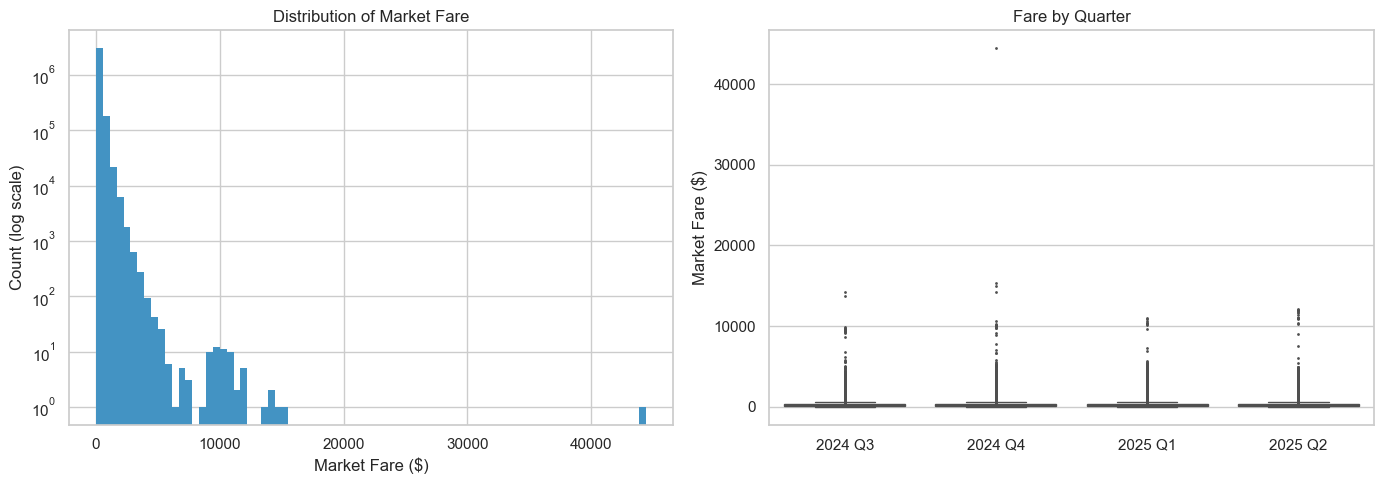

Fare statistics:
count    3.252027e+07
mean     2.710284e+02
std      2.215013e+02
min      1.100000e-01
50%      2.309200e+02
75%      3.398700e+02
95%      6.100000e+02
99%      1.084000e+03
max      4.443200e+04

Fares above $1,000: 1.2%


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution — log y scale
axes[0].hist(df_sample['MARKET_FARE'], bins=80, color=BLUE, edgecolor='none', log=True)
axes[0].set_xlabel('Market Fare ($)')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('Distribution of Market Fare')

# Box plot by quarter — seaborn supports `order`
df_sample['Quarter'] = df_sample['YEAR'].astype(str) + ' Q' + df_sample['QUARTER'].astype(str)
order = sorted(df_sample['Quarter'].unique())
sns.boxplot(data=df_sample, x='Quarter', y='MARKET_FARE', order=order,
            hue='Quarter', legend=False,
            ax=axes[1], palette='RdBu', fliersize=1)
axes[1].set_title('Fare by Quarter')
axes[1].set_xlabel('')
axes[1].set_ylabel('Market Fare ($)')

plt.tight_layout()
plt.show()

print("Fare statistics:")
print(df['MARKET_FARE'].describe(percentiles=[.5, .75, .95, .99]).to_string())
print(f"\nFares above $1,000: {(df['MARKET_FARE'] > 1000).mean():.1%}")

## 3. Graph Structure

Airports are nodes, routes are directed edges. Understanding the graph topology motivates the GNN — hub airports connect to many routes and influence neighboring pricing through competition.

Nodes (airports):       451
Edges (unique routes):  86,196
Avg routes per airport: 191.1


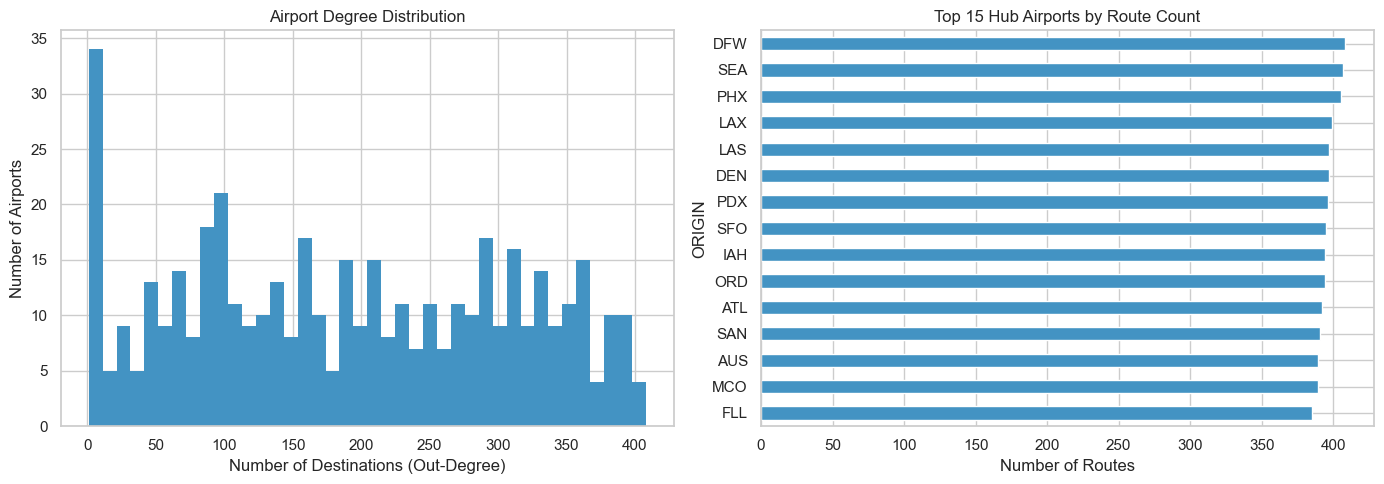

In [5]:
n_airports = df['ORIGIN'].nunique()
n_routes = df.groupby(['ORIGIN', 'DEST']).ngroups
print(f"Nodes (airports):       {n_airports:,}")
print(f"Edges (unique routes):  {n_routes:,}")
print(f"Avg routes per airport: {n_routes / n_airports:.1f}")

degree = df.groupby('ORIGIN')['DEST'].nunique().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(degree.values, bins=40, color=BLUE, edgecolor='none')
axes[0].set_xlabel('Number of Destinations (Out-Degree)')
axes[0].set_ylabel('Number of Airports')
axes[0].set_title('Airport Degree Distribution')

degree.head(15).plot(kind='barh', ax=axes[1], color=BLUE)
axes[1].invert_yaxis()
axes[1].set_xlabel('Number of Routes')
axes[1].set_title('Top 15 Hub Airports by Route Count')

plt.tight_layout()
plt.show()

## 4. Geographic Analysis

Latitude/longitude are node features in the GNN. Distance correlates with fare but is far from a perfect predictor — especially for hub airports where competition suppresses prices.

In [6]:
import hvplot.pandas
import holoviews as hv
hv.extension('bokeh')

# --- Distance vs Fare: hvplot + datashader (interactive, 3M sample points) ---
fare_cap = df_sample['MARKET_FARE'].quantile(0.99)
df_ds = df_sample[df_sample['MARKET_FARE'] <= fare_cap].copy()
df_ds['QUARTER'] = df_ds['QUARTER'].astype(str).astype('category')

plot = df_ds.hvplot.scatter(
    'MARKET_DISTANCE', 'MARKET_FARE',
    by='QUARTER',
    datashade=True,
    dynspread=True,
    color_key=Q_COLORS,
    width=700, height=450,
    xlabel='Market Distance (miles)',
    ylabel='Market Fare ($)',
    title='Distance vs Fare — 3M routes (datashader, colored by Quarter)'
)
plot

BokehModel(combine_events=True, render_bundle={'docs_json': {'48f02caa-f06b-416e-8fde-c53c2c0a8d58': {'version…

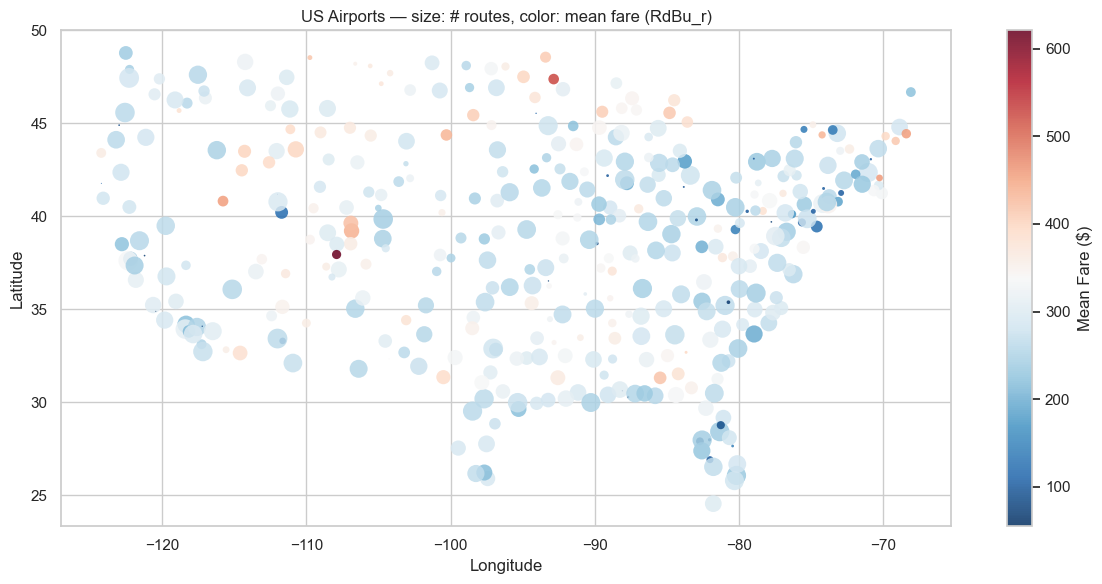

In [7]:
# --- US Airport Map: size = degree, color = mean fare (RdBu_r) ---
airport_stats = (
    df.groupby('ORIGIN')
    .agg(degree=('DEST', 'nunique'),
         mean_fare=('MARKET_FARE', 'mean'),
         lat=('ORIGIN_LAT', 'first'),
         lon=('ORIGIN_LON', 'first'))
    .reset_index()
)
us = airport_stats[airport_stats['lon'].between(-130, -65) & airport_stats['lat'].between(24, 50)]

fig, ax = plt.subplots(figsize=(12, 6))
sc = ax.scatter(us['lon'], us['lat'],
                s=us['degree'] * 0.5,
                c=us['mean_fare'], cmap='RdBu_r',
                alpha=0.85, edgecolors='none')
plt.colorbar(sc, ax=ax, label='Mean Fare ($)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('US Airports — size: # routes, color: mean fare (RdBu_r)')
plt.tight_layout()
plt.show()

## 5. Seasonal Patterns

Fares vary by quarter — summer and holiday periods show different pricing. Quarter is included as a cyclic edge feature in the GNN.

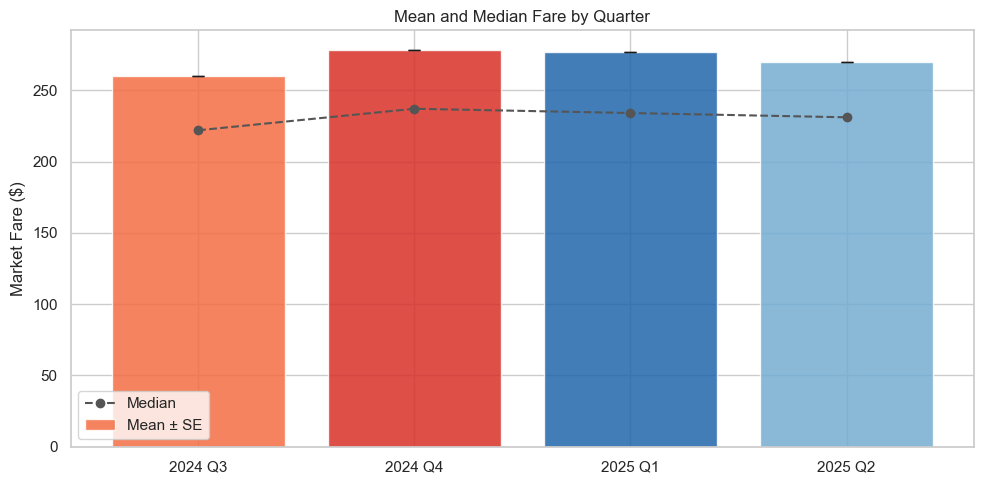

  label       mean  median        std
2024 Q3 260.079306  221.91 209.295214
2024 Q4 277.935632  237.00 224.431628
2025 Q1 277.024449  234.00 232.534054
2025 Q2 269.633725  231.00 219.962737


In [8]:
quarter_stats = (
    df.groupby(['YEAR', 'QUARTER'])['MARKET_FARE']
    .agg(mean='mean', median='median', std='std', n='count')
    .reset_index()
)
quarter_stats['label'] = quarter_stats['YEAR'].astype(str) + ' Q' + quarter_stats['QUARTER'].astype(str)

# Map each row to its RdBu_r quarter color
bar_colors = [Q_COLORS[str(q)] for q in quarter_stats['QUARTER']]

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(quarter_stats))
ax.bar(x, quarter_stats['mean'], yerr=quarter_stats['std'] / np.sqrt(quarter_stats['n']),
       color=bar_colors, alpha=0.85, capsize=4, label='Mean ± SE')
ax.plot(x, quarter_stats['median'], 'o--', color='#555555', label='Median')
ax.set_xticks(list(x))
ax.set_xticklabels(quarter_stats['label'])
ax.set_ylabel('Market Fare ($)')
ax.set_title('Mean and Median Fare by Quarter')
ax.legend()
plt.tight_layout()
plt.show()

print(quarter_stats[['label', 'mean', 'median', 'std']].to_string(index=False))

## 6. Carrier Effects

Different carriers price routes differently. Carrier is encoded as an edge feature in the GNN.

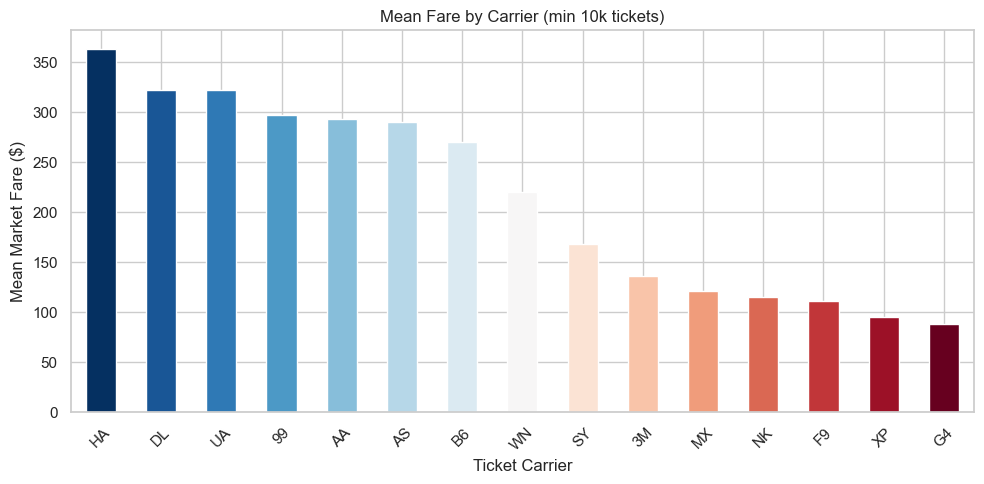

                 mean_fare  n_tickets
TICKET_CARRIER                       
HA              363.655953     262968
DL              322.064811    6389832
UA              321.975771    5569627
99              297.534914     516507
AA              292.979862    7521396
AS              290.196611    1596197
B6              270.701998     716341
WN              220.230433    6893321
SY              168.187841      60390
3M              136.365888      11185
MX              120.938665     225615
NK              115.712563    1062158
F9              111.127127     980136
XP               95.807170      85220
G4               87.941935     628275


In [9]:
carrier_fare = (
    df.groupby('TICKET_CARRIER')['MARKET_FARE']
    .agg(mean_fare='mean', n_tickets='count')
    .query('n_tickets >= 10000')
    .sort_values('mean_fare', ascending=False)
    .head(15)
)

# Color bars by rank using RdBu_r (highest fare = red, lowest = blue)
n = len(carrier_fare)
cmap = plt.cm.RdBu_r
colors = [cmap(i / (n - 1)) for i in range(n)]

fig, ax = plt.subplots(figsize=(10, 5))
carrier_fare['mean_fare'].plot(kind='bar', ax=ax, color=colors)
ax.set_xlabel('Ticket Carrier')
ax.set_ylabel('Mean Market Fare ($)')
ax.set_title('Mean Fare by Carrier (min 10k tickets)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print(carrier_fare.to_string())

## 7. Feature Correlations

Distance and mileage are the strongest numeric predictors of fare, but the correlation is far from perfect — motivating graph neighborhood context (e.g., hub vs. regional airport) as additional signal.

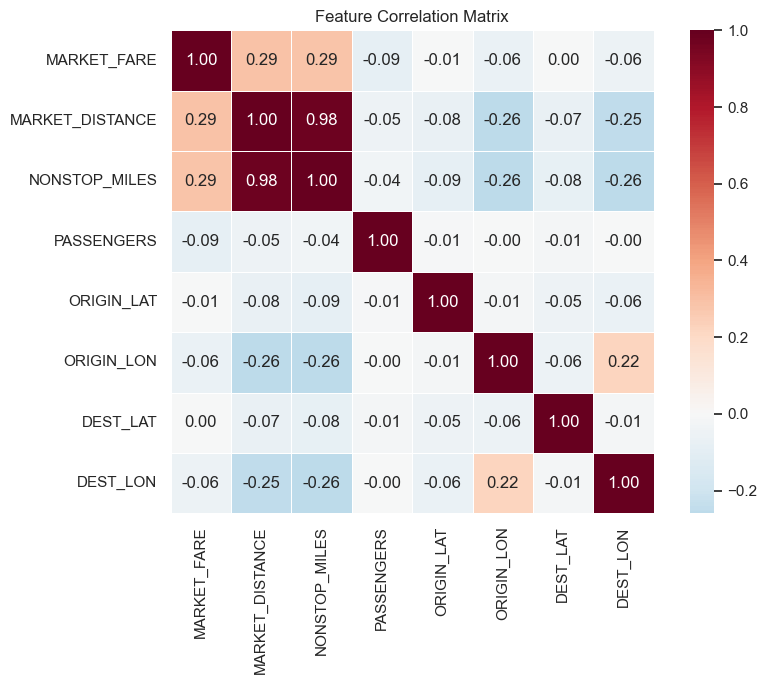

In [10]:
num_cols = ['MARKET_FARE', 'MARKET_DISTANCE', 'NONSTOP_MILES',
            'PASSENGERS', 'ORIGIN_LAT', 'ORIGIN_LON', 'DEST_LAT', 'DEST_LON']

corr = df_sample[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 8. Route-Level Fare Variance

The same route (ORIGIN → DEST) has significant fare variance across quarters and carriers. This motivates using temporal and graph-contextual features rather than simple distance-based regression.

Routes with ≥20 observations: 42,504

Within-route fare std dev:
count    42504.000000
mean       189.959085
std        103.465106
min          6.764645
25%        141.170980
50%        170.108550
75%        213.508017
max       9854.708557


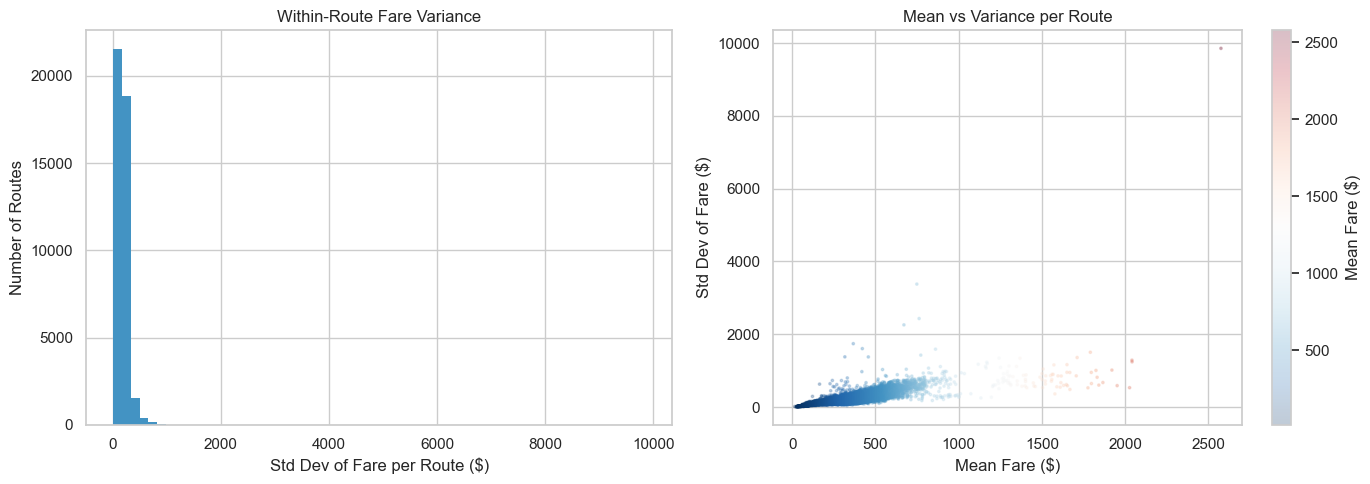

In [11]:
route_stats = (
    df.groupby(['ORIGIN', 'DEST'])['MARKET_FARE']
    .agg(mean_fare='mean', std_fare='std', n_obs='count')
    .query('n_obs >= 20')
    .reset_index()
)

print(f"Routes with ≥20 observations: {len(route_stats):,}")
print(f"\nWithin-route fare std dev:")
print(route_stats['std_fare'].describe().to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(route_stats['std_fare'].dropna(), bins=60, color=BLUE, edgecolor='none')
axes[0].set_xlabel('Std Dev of Fare per Route ($)')
axes[0].set_ylabel('Number of Routes')
axes[0].set_title('Within-Route Fare Variance')

sc = axes[1].scatter(route_stats['mean_fare'], route_stats['std_fare'],
                     c=route_stats['mean_fare'], cmap='RdBu_r',
                     alpha=0.25, s=3)
plt.colorbar(sc, ax=axes[1], label='Mean Fare ($)')
axes[1].set_xlabel('Mean Fare ($)')
axes[1].set_ylabel('Std Dev of Fare ($)')
axes[1].set_title('Mean vs Variance per Route')

plt.tight_layout()
plt.show()